# Rakamin X ID/X Partners Data Scientist Project Based Internship Program

## Task 3: Exploratory Data Analysis

### Library Import

In [ ]:
from pymongo import MongoClient
from WordCloud import WordCloud
from scipy import stats
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn import linear_model
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, cohen_kappa_score, classification_report
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore') 

### Data Extraction

In [72]:
client = MongoClient("mongodb://localhost:27017/")
collection = client["lendingclub_db"]["loans_clean"]
df = pd.DataFrame(list(collection.find()))

# Drop the MongoDB internal _id column
df = df.drop(columns=["_id"])
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,12000,12000,12000.0,36,13.53,407.40,B,B5,On road manager,10,...,0.0,119.17,0.0,53.0,1,INDIVIDUAL,0.0,15386.0,13605.0,8100.0
1,3000,3000,3000.0,36,12.85,100.87,B,B4,Auditor,10,...,0.0,2677.23,0.0,69.0,1,INDIVIDUAL,0.0,154.0,19530.0,5300.0
2,7200,7200,7200.0,36,10.99,235.69,B,B2,executive administrator,4,...,0.0,4539.95,0.0,59.0,1,INDIVIDUAL,0.0,0.0,45598.0,9800.0
3,9000,9000,9000.0,36,14.98,311.90,C,C3,Category Manager,10,...,0.0,5114.64,0.0,70.0,1,INDIVIDUAL,0.0,4009.0,80436.0,37200.0
4,16000,16000,16000.0,60,19.22,416.99,D,D4,District Sales Manager,8,...,0.0,416.99,0.0,60.0,1,INDIVIDUAL,0.0,0.0,188654.0,22600.0


To Analyze:
1. Target variable distribution        ← bar chart, raw labels
2. Numeric distributions               ← histograms, log scale where needed
3. Correlation matrix heatmap          ← replaces all scatterplots
4. Grade/sub-grade vs default rate     ← heatmap
5. Employment length vs loan metrics   ← box plot
6. Grade and loan status               ← stacked bar (not pie)
7. Purpose vs loan status              ← stacked bar

#### 1. Target variable value distribution

In [73]:
df['loan_status'].value_counts()

loan_status
Fully Paid            5178
Charged Off           1138
Late (31-120 days)     313
In Grace Period        137
Late (16-30 days)       70
Default                 38
Name: count, dtype: int64

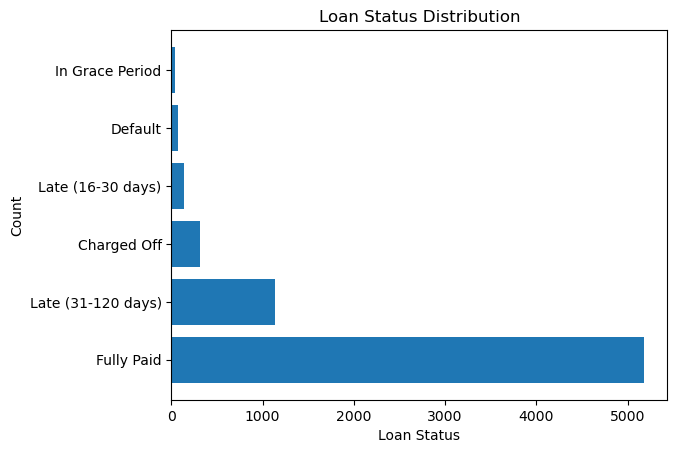

In [74]:
plt.barh(df['loan_status'].unique(), df['loan_status'].value_counts())
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

#### 2. Numerical Value Distribution

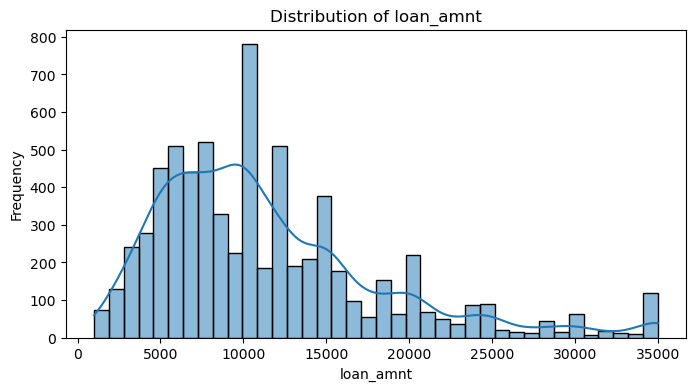

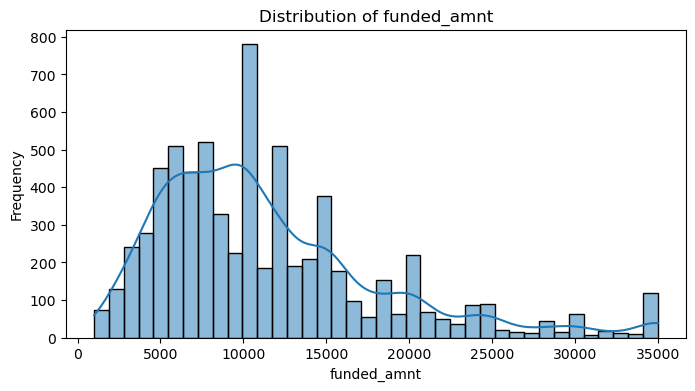

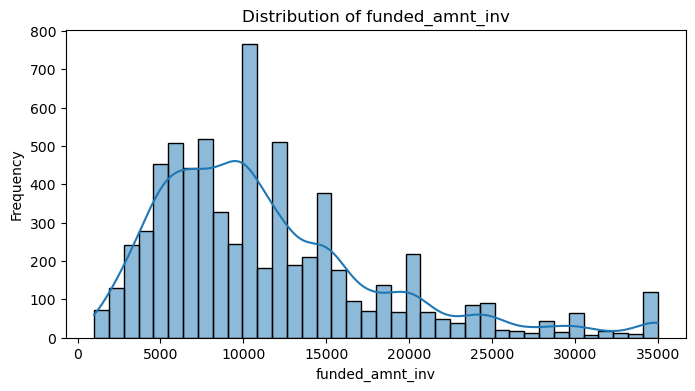

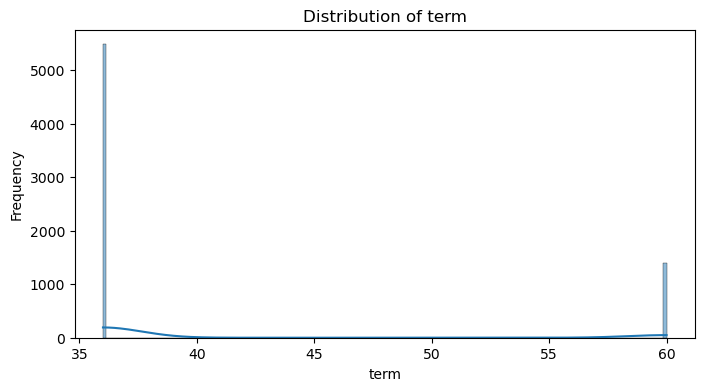

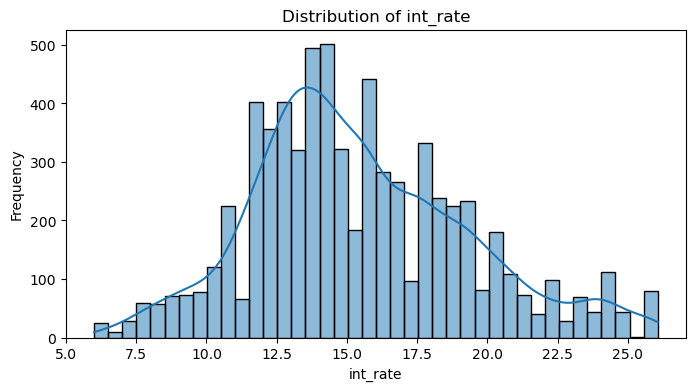

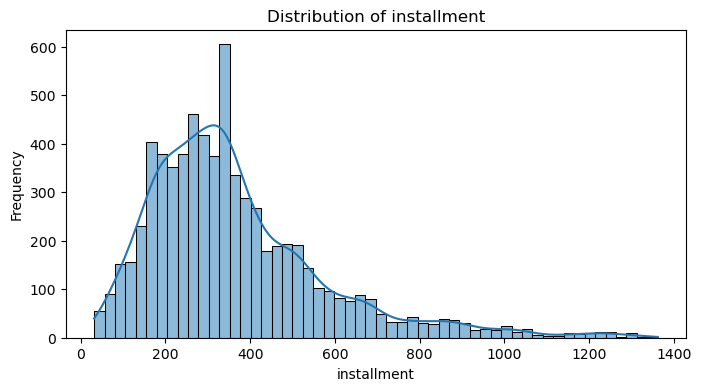

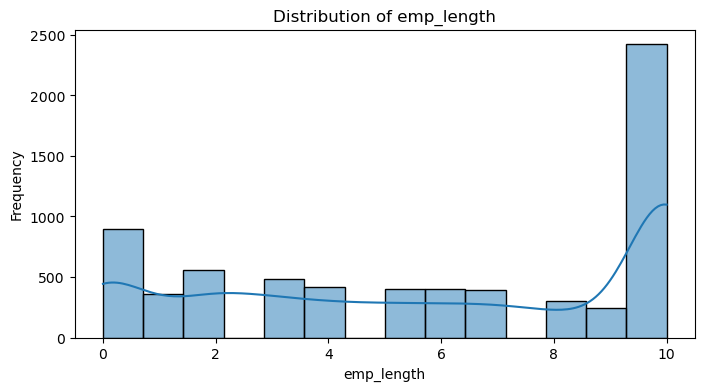

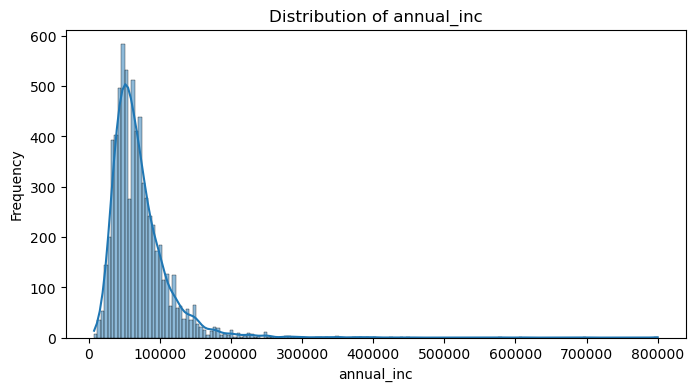

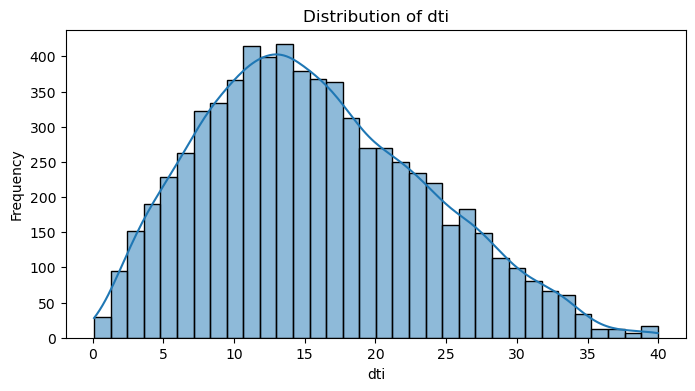

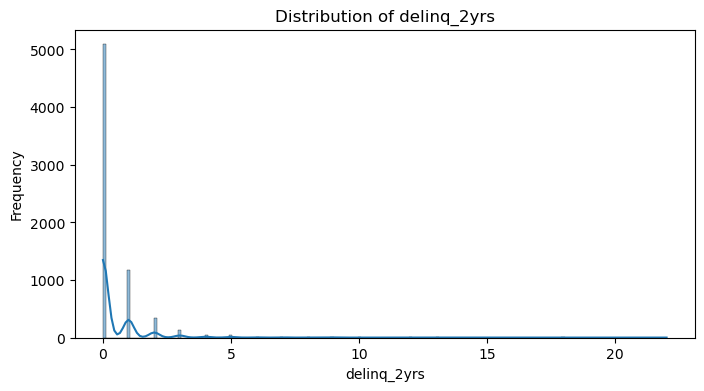

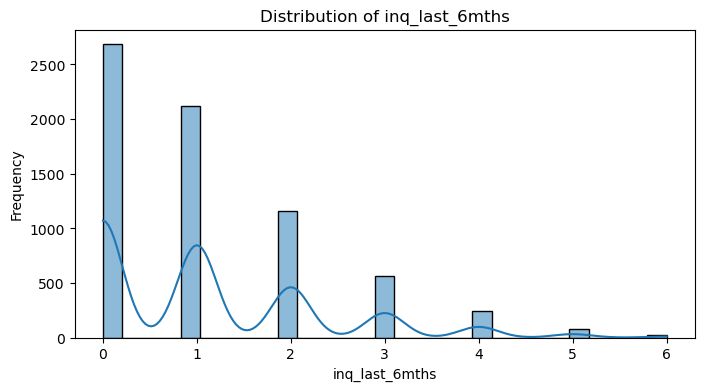

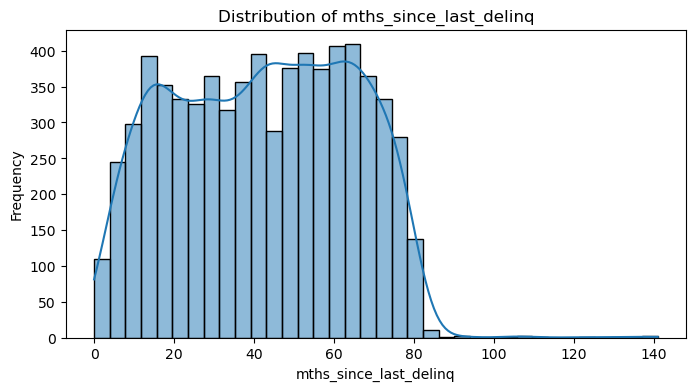

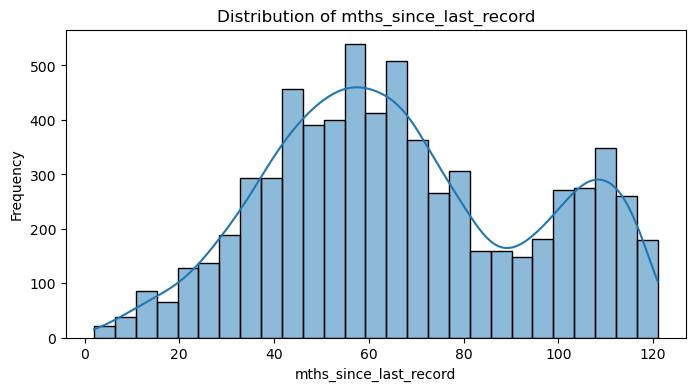

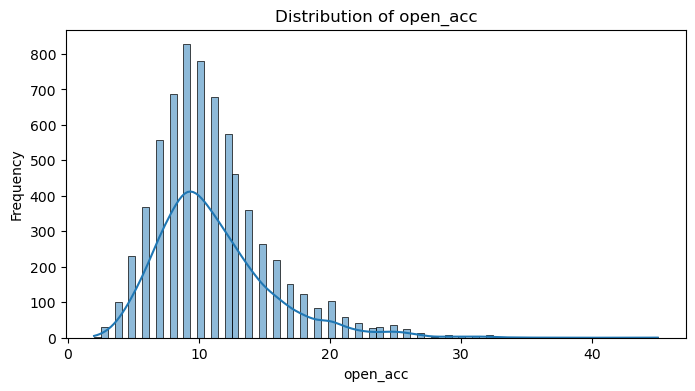

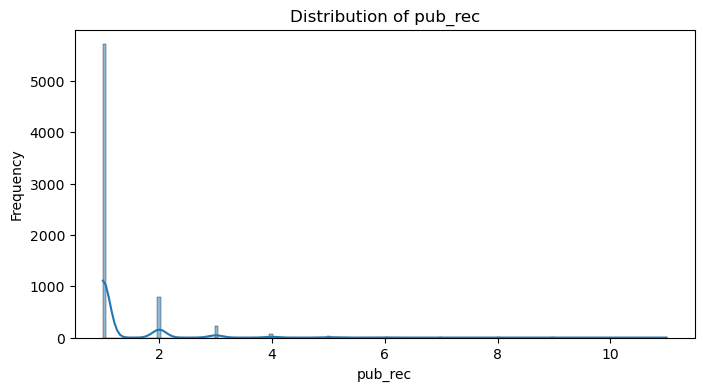

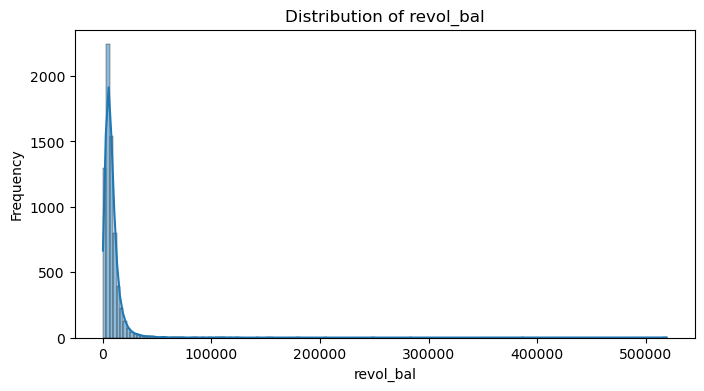

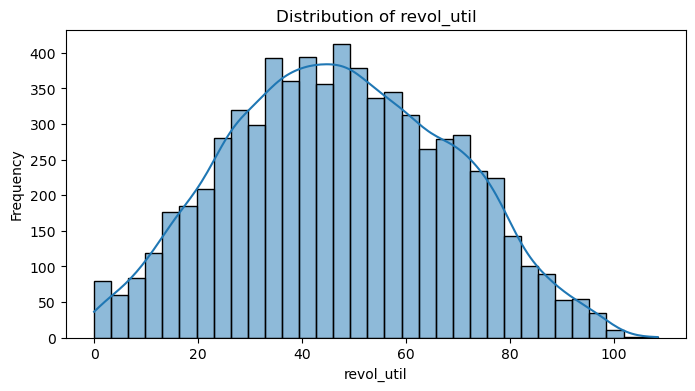

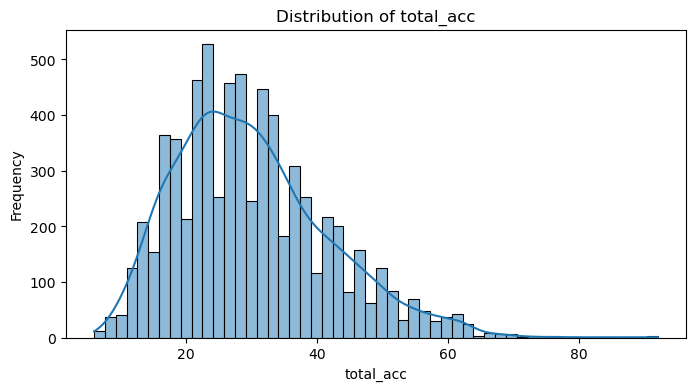

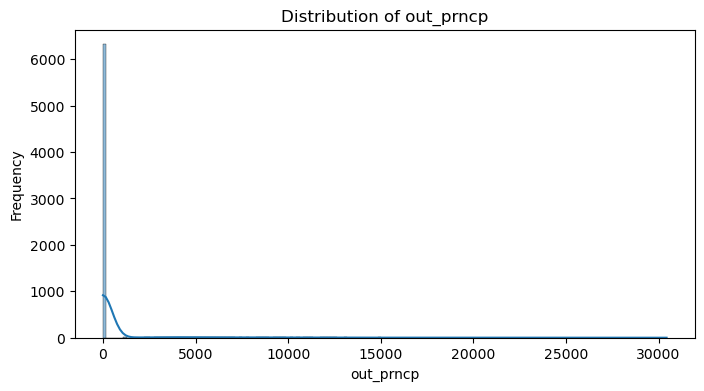

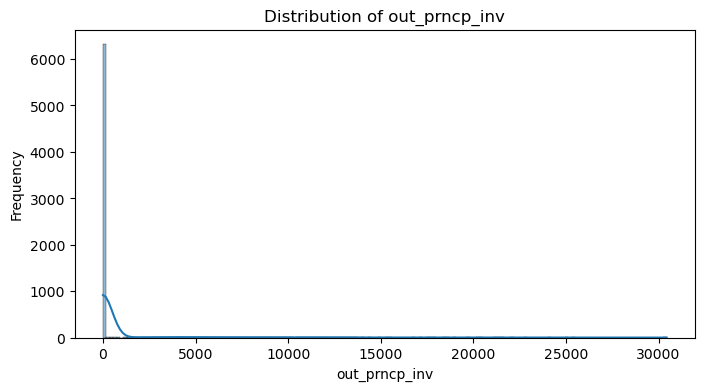

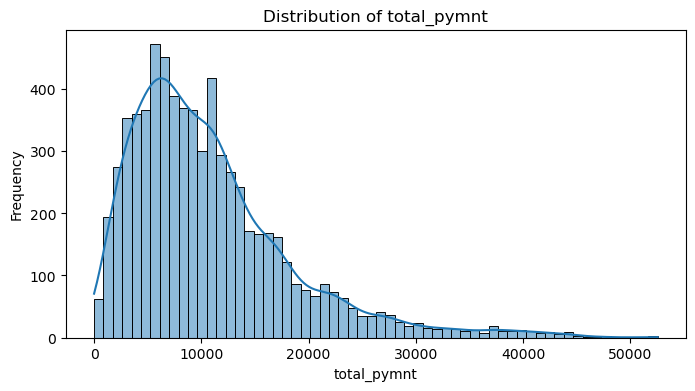

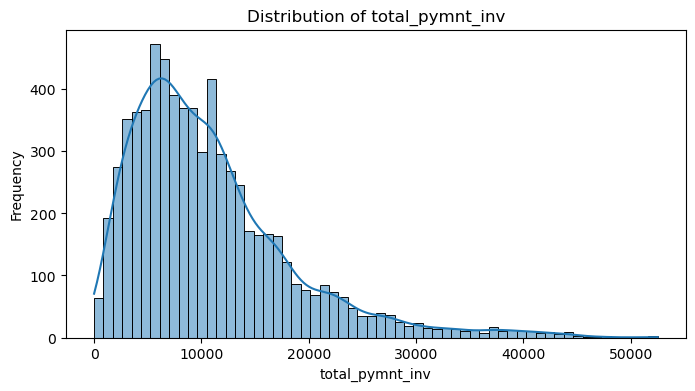

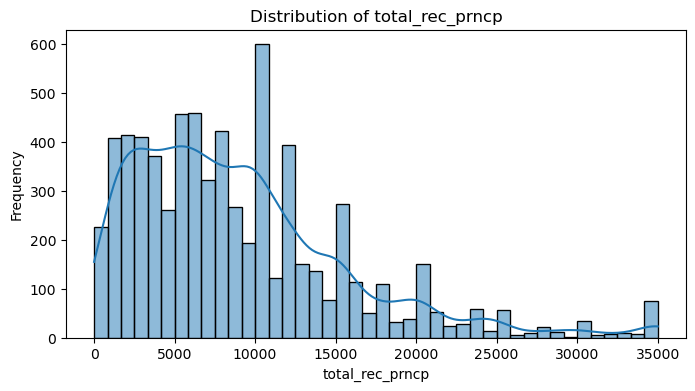

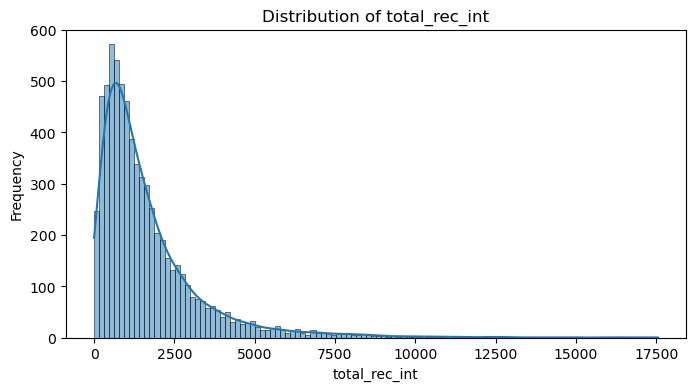

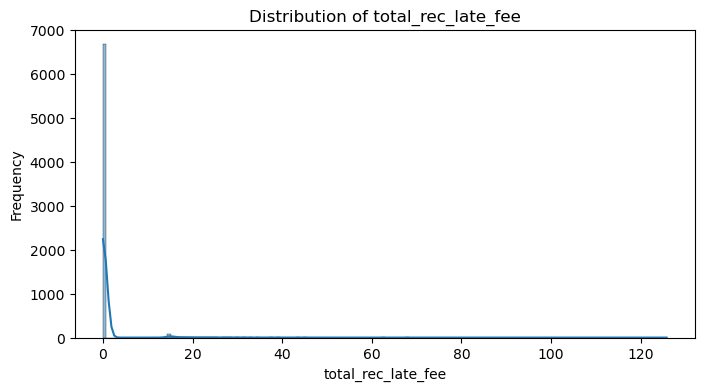

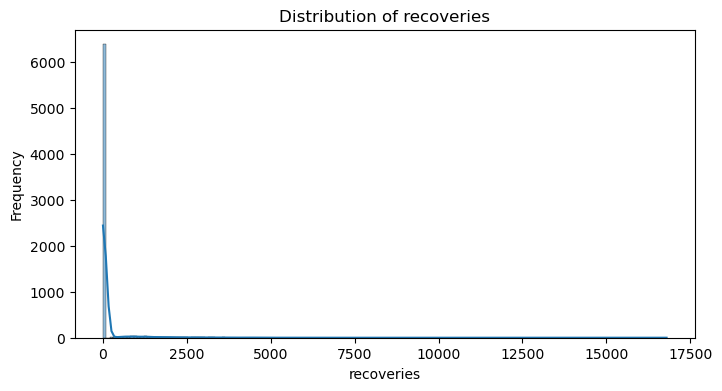

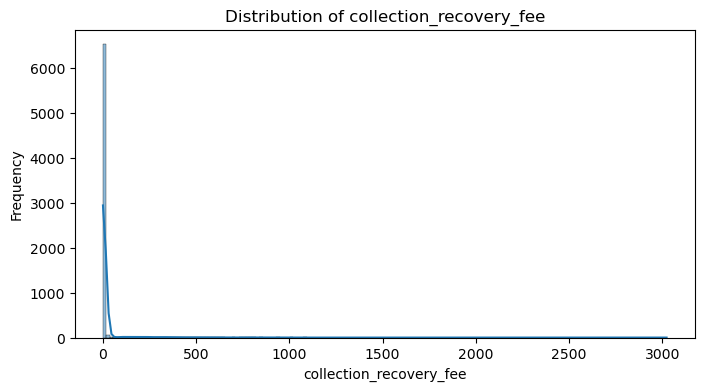

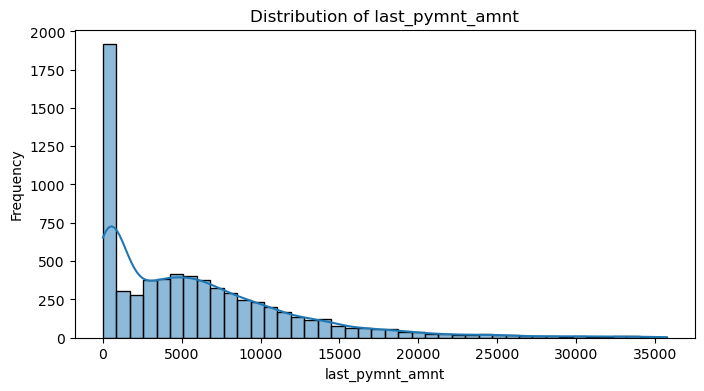

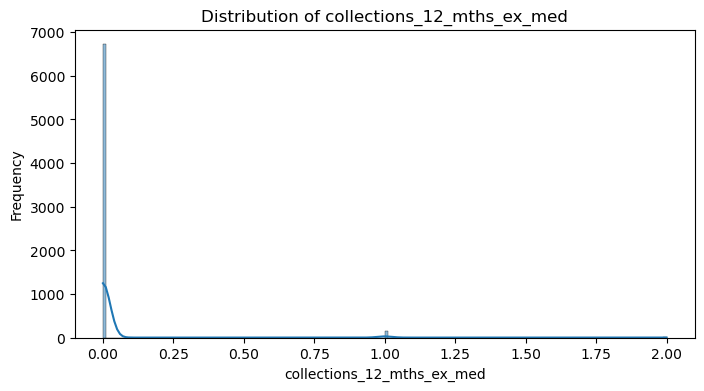

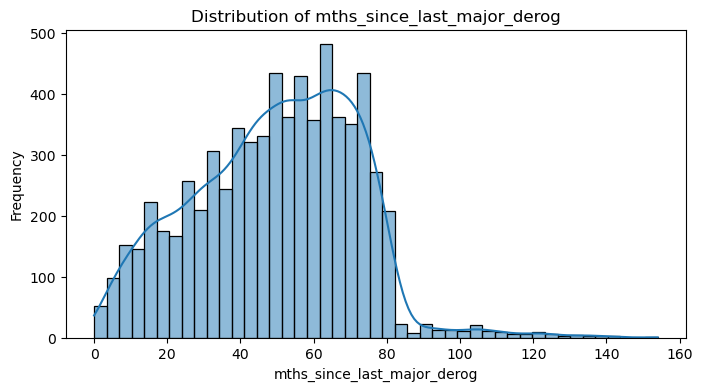

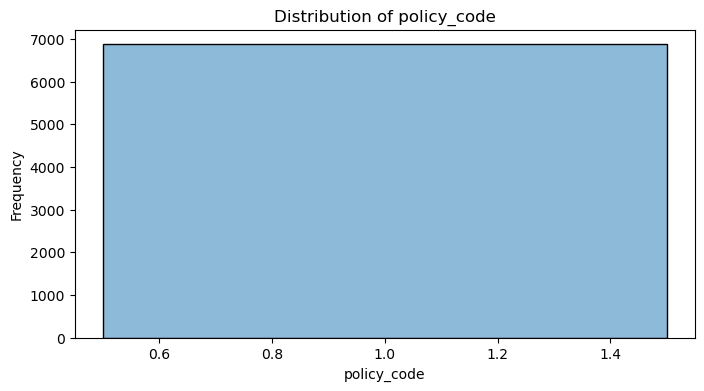

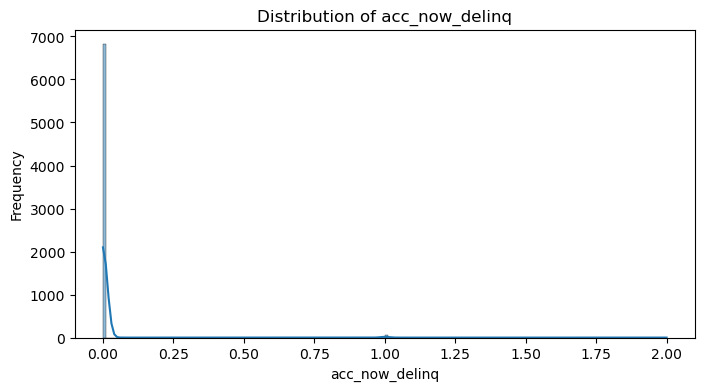

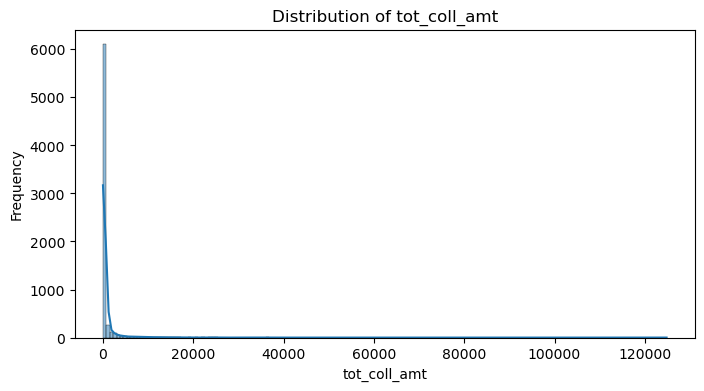

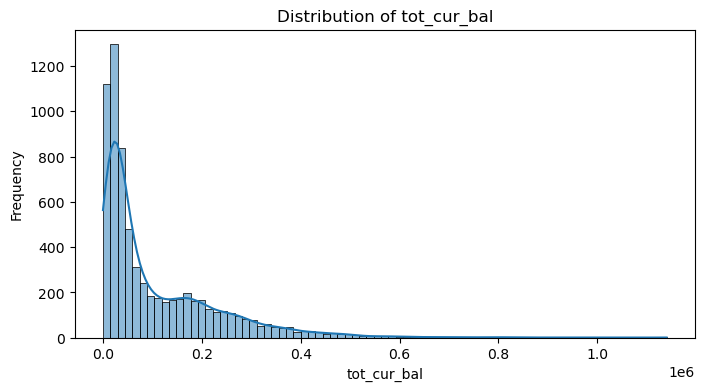

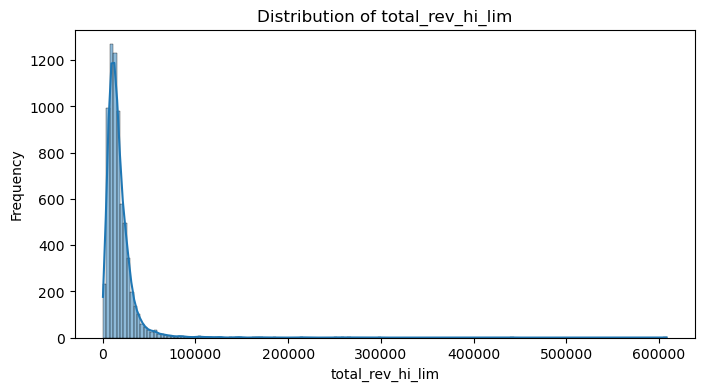

In [75]:
for col in df.columns:
    if df[col].dtype != 'object' and df[col].dtype != 'datetime64[ns]':
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

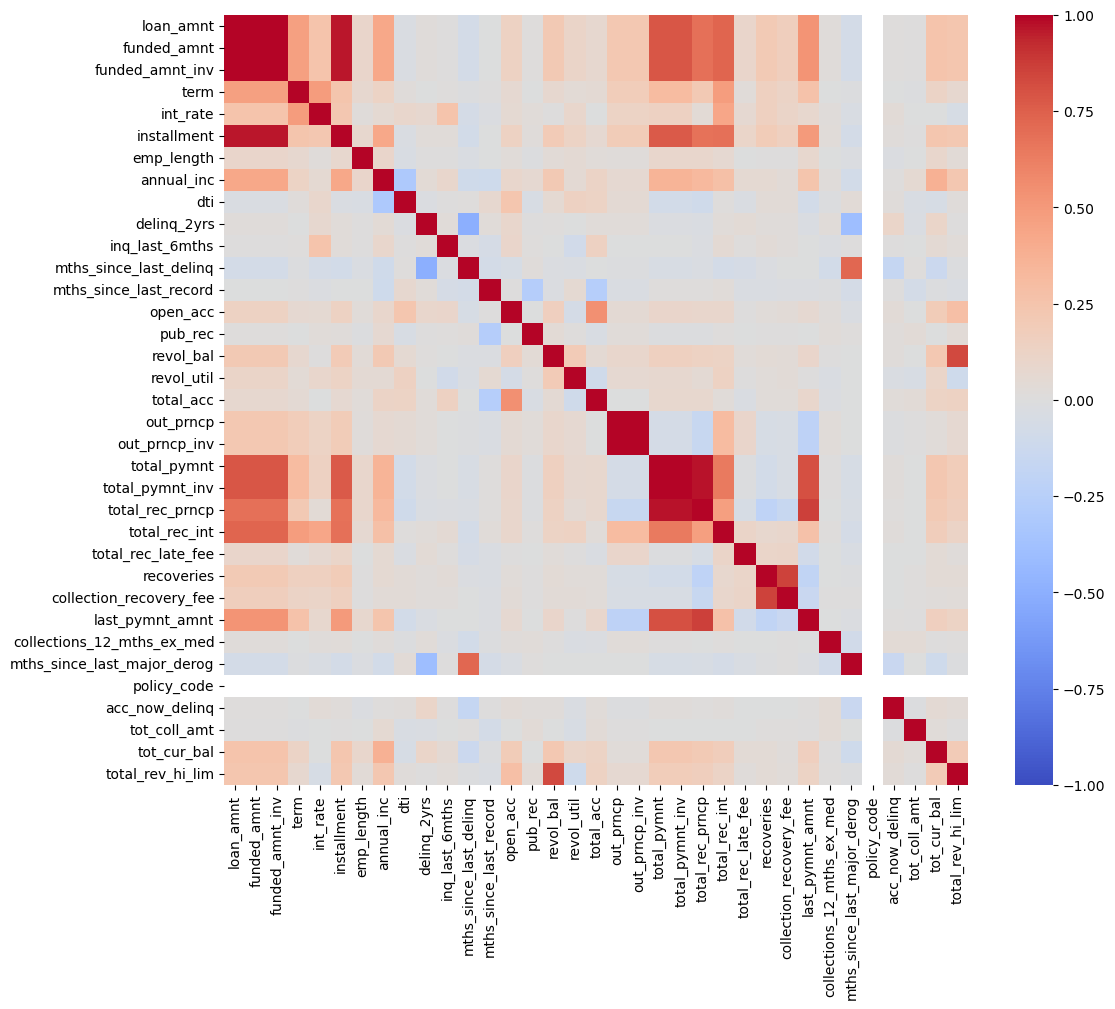

In [76]:
data = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,10))
sns.heatmap(data, vmin=-1, vmax=1, cmap='coolwarm', annot=False, fmt='.2f')
plt.show()

In [77]:
df['loan_status'].unique()

array(['Fully Paid', 'Late (31-120 days)', 'Charged Off',
       'Late (16-30 days)', 'Default', 'In Grace Period'], dtype=object)

In [78]:
grade_list = [i for i in df['grade'].unique()]
print(grade_list)

['B', 'C', 'D', 'A', 'F', 'E', 'G']


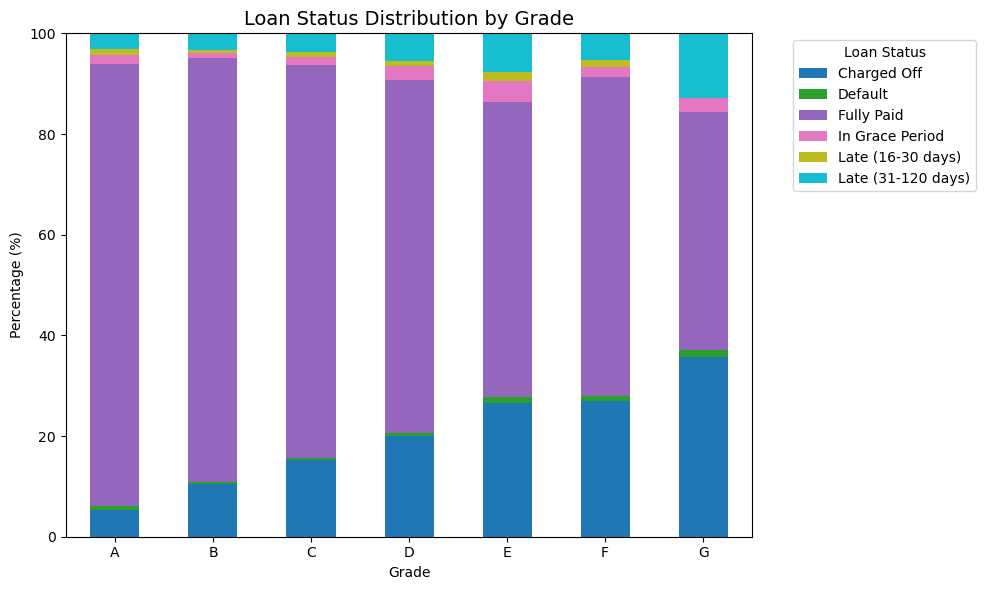

In [79]:
# Calculate percentage of each loan_status per grade
grade_status = (
    df.groupby(['grade', 'loan_status'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages
grade_status_pct = grade_status.div(grade_status.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = grade_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab10',
    edgecolor='none'
)

# Formatting
plt.title('Loan Status Distribution by Grade', fontsize=14)
plt.xlabel('Grade')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [80]:
df[df['emp_title']=='unemployed']['loan_status'].value_counts()

loan_status
Fully Paid            387
Charged Off           119
Late (31-120 days)     25
In Grace Period         6
Late (16-30 days)       4
Default                 1
Name: count, dtype: int64

In [81]:
df[df['emp_title']!='unemployed']['loan_status'].value_counts()

loan_status
Fully Paid            4791
Charged Off           1019
Late (31-120 days)     288
In Grace Period        131
Late (16-30 days)       66
Default                 37
Name: count, dtype: int64

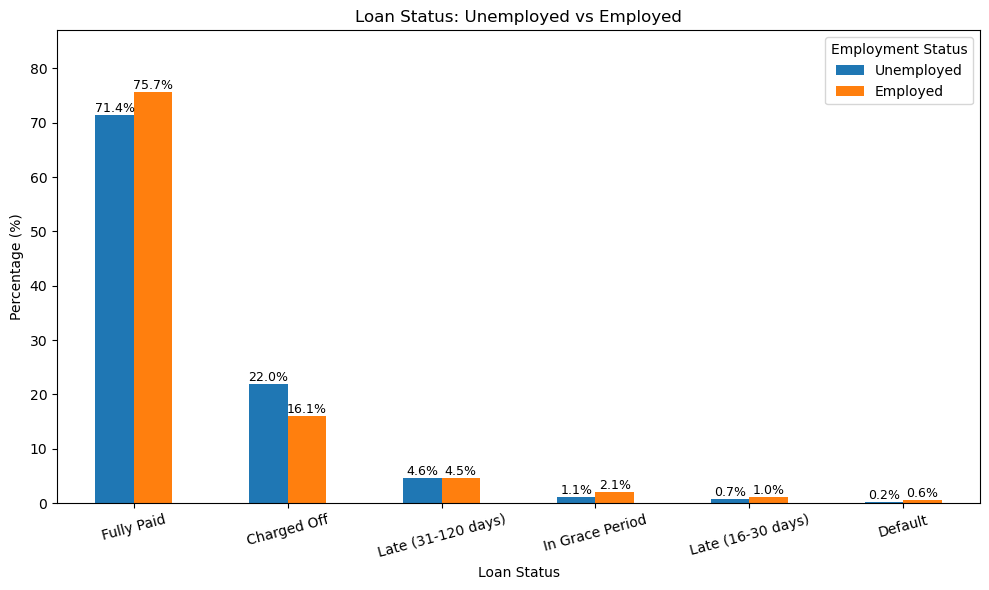

In [82]:
# Calculate percentages for each group
unemployed = (
    df[df['emp_title'] == 'unemployed']['loan_status']
    .value_counts(normalize=True) * 100
)

employed = (
    df[df['emp_title'] != 'unemployed']['loan_status']
    .value_counts(normalize=True) * 100
)

# Combine into a single DataFrame
compare_df = pd.DataFrame({
    'Unemployed': unemployed,
    'Employed': employed
}).fillna(0)

# Plot
ax = compare_df.plot(kind='bar', figsize=(10, 6), edgecolor='none')

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=9
    )

plt.title('Loan Status: Unemployed vs Employed')
plt.xlabel('Loan Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.ylim(0, compare_df.values.max() * 1.15)
plt.legend(title='Employment Status')
plt.tight_layout()
plt.show()

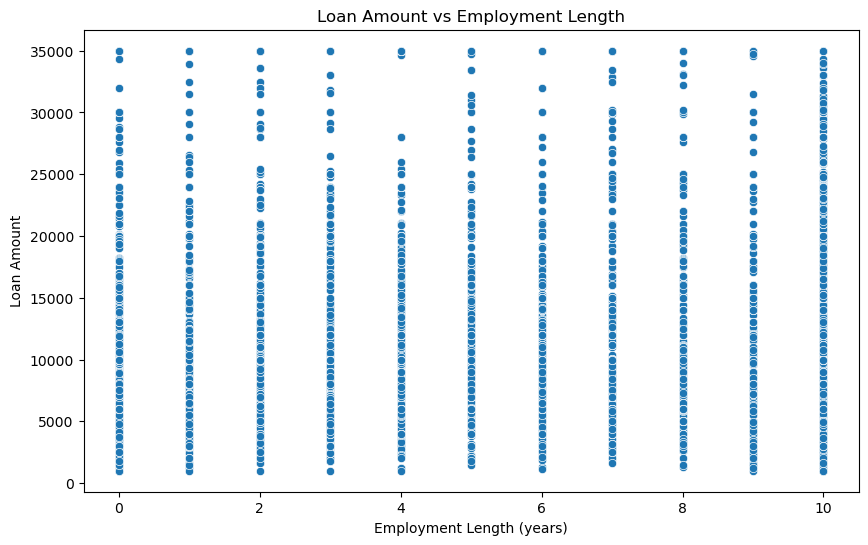

In [83]:
emp_length=df['emp_length']
borrowed=df['loan_amnt']
data = pd.DataFrame({'emp_length': emp_length, 'loan_amnt': borrowed})
plt.figure(figsize=(10, 6))
sns.scatterplot(x='emp_length', y='loan_amnt', data=data)
plt.title('Loan Amount vs Employment Length')
plt.xlabel('Employment Length (years)')
plt.ylabel('Loan Amount')
plt.show()

### Feature Engineering

In [84]:
y=df['loan_status']
X=df.drop(columns=['loan_status'])
y.replace({'Fully Paid': 0, 'In Grace Period': 1, 'Late (16-30 days)': 2, 'Late (31-120 days)': 3, 'Default': 4, 'Charged Off': 5}, inplace=True)

In [85]:
cat_cols = list(X.select_dtypes(include='object').columns)

listItem = []
for col in cat_cols:
  listItem.append([col, X[col].nunique(), X[col].unique()])

pd.DataFrame(columns=['Column', 'Unique Values Total', 'Unique Values'], data=listItem)

,Column,Unique Values Total,Unique Values
0,grade,7,"[B, C, D, A, F, E, G]"
1,sub_grade,35,"[B5, B4, B2, C3, D4, C2, C4, B3, C1, D1, A4, F..."
2,emp_title,4487,"[On road manager, Auditor, executive administr..."
3,home_ownership,3,"[RENT, OWN, MORTGAGE]"
4,verification_status,3,"[Source Verified, Verified, Not Verified]"
5,pymnt_plan,1,[n]
6,purpose,13,"[debt_consolidation, home_improvement, credit_..."
7,title,1019,"[Debt consolidation, debt, loan payoffs, conso..."
8,zip_code,695,"[871xx, 322xx, 906xx, 482xx, 277xx, 631xx, 240..."
9,addr_state,46,"[NM, FL, CA, MI, NC, MO, VA, NJ, WV, OH, NY, M..."


In [86]:
X['emp_status'] = X['emp_title'].apply(lambda a: 'unemployed' if a == 'unemployed' else 'employed')

# Drop the original column
X = X.drop(columns=['emp_title'])
X.drop(columns=['sub_grade','pymnt_plan','purpose','title','zip_code','addr_state'], inplace=True)

In [87]:
y.value_counts()

loan_status
0    5178
5    1138
3     313
1     137
2      70
4      38
Name: count, dtype: int64

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [89]:
num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(X_train[col].skew(),1), np.where(
    (round(X_train[col].skew(),1) <= 0.5) & (round(X_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])



skewness = pd.DataFrame(columns=['Column', 'Skewness', 'Distribution'], data= listItem)
skewness

,Column,Skewness,Distribution
0,loan_amnt,1.3,skewed
1,funded_amnt,1.3,skewed
2,funded_amnt_inv,1.3,skewed
3,term,1.5,skewed
4,int_rate,0.5,normal
5,installment,1.5,skewed
6,emp_length,-0.3,normal
7,annual_inc,3.9,skewed
8,dti,0.4,normal
9,delinq_2yrs,6.2,skewed


In [90]:
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['Column'][row]
  #checking upper and lower boundary
  if skewness['Distribution'][row] == 'skewed':
    IQR = X_train[col].quantile(0.75) - X_train[col].quantile(0.25)
    lower_boundary = X_train[col].quantile(0.25) - (IQR * 3)
    upper_boundary = X_train[col].quantile(0.75) + (IQR * 3)
  else:
    lower_boundary = X_train[col].mean() - 3* X_train[col].std()
    upper_boundary = X_train[col].mean() + 3* X_train[col].std()
  #append to list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(X_train[X_train[col] > upper_boundary]) / len(X_train) * 100) + (len(X_train[X_train[col] < lower_boundary]) / len(X_train) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    #round the value
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [round(percent_total_outlier,2) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,loan_amnt,40500.00,-19000.00,0.00
1,funded_amnt,40500.00,-19000.00,0.00
2,funded_amnt_inv,40500.00,-19000.00,0.00
3,term,36.00,36.00,20.41
4,int_rate,26.95,3.95,0.00
5,installment,1158.79,-483.62,0.89
6,emp_length,17.26,-5.45,0.00
7,annual_inc,205000.00,-75000.00,1.18
8,dti,39.11,-7.75,0.16
9,delinq_2yrs,4.00,-3.00,1.49


In [91]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"Column: {col}")
        print(X[col].value_counts())
        print("\n")

Column: grade
grade
C    2226
B    1864
D    1474
E     744
F     268
A     228
G      70
Name: count, dtype: int64


Column: home_ownership
home_ownership
MORTGAGE    3372
RENT        2909
OWN          593
Name: count, dtype: int64


Column: verification_status
verification_status
Verified           2779
Source Verified    2745
Not Verified       1350
Name: count, dtype: int64


Column: initial_list_status
initial_list_status
f    4036
w    2838
Name: count, dtype: int64


Column: application_type
application_type
INDIVIDUAL    6874
Name: count, dtype: int64


Column: emp_status
emp_status
employed      6332
unemployed     542
Name: count, dtype: int64




- grade=ordinal-->A-G
- home_ownership=one hot
- verification_status=ordinal-->Source Verified, Verified, Not Verified
- initial_list_status=one hot
- emp_status=ordinal-->unemployed:0, employed:1

Note: application_type should be removed

In [92]:
num_features_scaler= []
num_features_minmax = []
for col in outliers['column']:
  if -1<=outliers[outliers['column'] == col]['percentage_total_outlier'].values[0] <=1 :
    num_features_scaler.append(col)
  else:
    num_features_minmax.append(col)



In [93]:
ordinal_features = ['grade', 'emp_status','verification_status']
onehot_features = ['home_ownership', 'initial_list_status']

In [94]:
grade_ordinal = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_ord = OrdinalEncoder(categories=[grade_ordinal], dtype=int)
emp_status_ordinal = ['unemployed', 'employed']
emp_status_ord = OrdinalEncoder(categories=[emp_status_ordinal], dtype=int)
verification_status_ordinal = ['Not Verified', 'Source Verified', 'Verified']
verification_status_ord = OrdinalEncoder(categories=[verification_status_ordinal], dtype=int)

In [95]:
numerical_transformer_scaler = Pipeline(steps=[
    ('scaler', StandardScaler())
])
numerical_transformer_minmax = Pipeline(steps=[
    ('minmax', MinMaxScaler())
])
categorical_transformer_onehot = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
categorical_transformer_ordinal = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

In [96]:
preprocessor = ColumnTransformer(transformers=[
    ('num_scaler', numerical_transformer_scaler, num_features_scaler),
    ('num_minmax', numerical_transformer_minmax, num_features_minmax),
    ('cat_onehot', categorical_transformer_onehot, onehot_features),
    # Each ordinal feature gets its own encoder with the correct category order
    ('cat_grade', Pipeline(steps=[('ordinal', grade_ord)]), ['grade']),
    ('cat_emp_status', Pipeline(steps=[('ordinal', emp_status_ord)]), ['emp_status']),
    ('cat_verification', Pipeline(steps=[('ordinal', verification_status_ord)]), ['verification_status']),
])

smote = SMOTE(sampling_strategy='minority', k_neighbors=5, random_state=42)


In [97]:
def array_to_dataframe(X, columns):
    """Convert numpy array back to DataFrame for ColumnTransformer compatibility."""
    return pd.DataFrame(X, columns=columns)

In [98]:
# Check the transformed shape and column names after preprocessing
X_transformed = preprocessor.fit_transform(X_train)
print(f"Transformed shape: {X_transformed.shape}")
print(f"Transformed columns: {preprocessor.get_feature_names_out()}")


Transformed shape: (5155, 41)
Transformed columns: ['num_scaler__loan_amnt' 'num_scaler__funded_amnt'
 'num_scaler__funded_amnt_inv' 'num_scaler__int_rate'
 'num_scaler__installment' 'num_scaler__emp_length' 'num_scaler__dti'
 'num_scaler__inq_last_6mths' 'num_scaler__mths_since_last_delinq'
 'num_scaler__mths_since_last_record' 'num_scaler__open_acc'
 'num_scaler__revol_util' 'num_scaler__total_acc'
 'num_scaler__total_pymnt' 'num_scaler__total_pymnt_inv'
 'num_scaler__total_rec_prncp' 'num_scaler__last_pymnt_amnt'
 'num_scaler__mths_since_last_major_derog' 'num_scaler__policy_code'
 'num_scaler__acc_now_delinq' 'num_scaler__tot_cur_bal' 'num_minmax__term'
 'num_minmax__annual_inc' 'num_minmax__delinq_2yrs' 'num_minmax__pub_rec'
 'num_minmax__revol_bal' 'num_minmax__out_prncp'
 'num_minmax__out_prncp_inv' 'num_minmax__total_rec_int'
 'num_minmax__total_rec_late_fee' 'num_minmax__recoveries'
 'num_minmax__collection_recovery_fee'
 'num_minmax__collections_12_mths_ex_med' 'num_minmax__t

In [99]:
pipe_logreg = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('FunctionTransformer', FunctionTransformer(func=array_to_dataframe, kw_args={'columns': preprocessor.get_feature_names_out()})),
    ('classifier', linear_model.LogisticRegression(random_state=42))
])

In [100]:
pipe_logreg.fit(X_train, y_train)
y_pred_logreg = pipe_logreg.predict(X_test)

In [110]:
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1292
           1       0.00      0.00      0.00        28
           2       0.00      0.00      0.00        24
           3       0.61      0.25      0.36        76
           4       0.09      0.90      0.17        10
           5       0.98      0.98      0.98       289

    accuracy                           0.93      1719
   macro avg       0.45      0.52      0.42      1719
weighted avg       0.94      0.93      0.93      1719



In [111]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_logreg)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_logreg, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.1216
Cohen's Kappa (quadratic): 0.9629


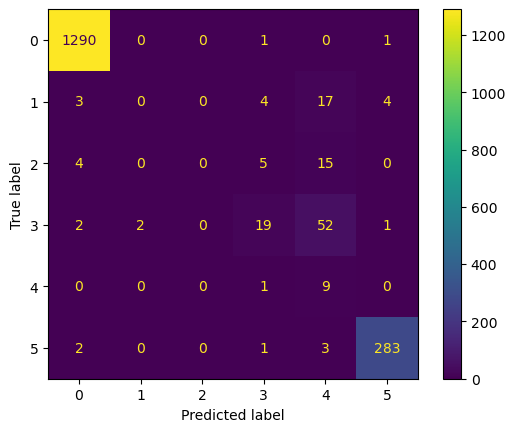

In [112]:
cm_test= confusion_matrix(y_test, y_pred_logreg)
ConfusionMatrixDisplay(cm_test).plot()

In [113]:
eval_logreg = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [
        cm_test[1][0],  # False Negatives
        mae,
        kappa
    ]
}

In [115]:
pipe_rf= ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('FunctionTransformer', FunctionTransformer(func=array_to_dataframe, kw_args={'columns': preprocessor.get_feature_names_out()})),
    ('classifier', RandomForestClassifier(random_state=42))])


In [116]:
pipe_rf.fit(X_train, y_train)
y_pred_randfor= pipe_rf.predict(X_test)

In [117]:
print(classification_report(y_test, y_pred_randfor))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1292
           1       0.00      0.00      0.00        28
           2       1.00      0.04      0.08        24
           3       0.57      0.86      0.68        76
           4       0.12      0.20      0.15        10
           5       1.00      0.99      0.99       289

    accuracy                           0.96      1719
   macro avg       0.61      0.51      0.48      1719
weighted avg       0.96      0.96      0.95      1719



In [118]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_randfor)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_randfor, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0745
Cohen's Kappa (quadratic): 0.9772


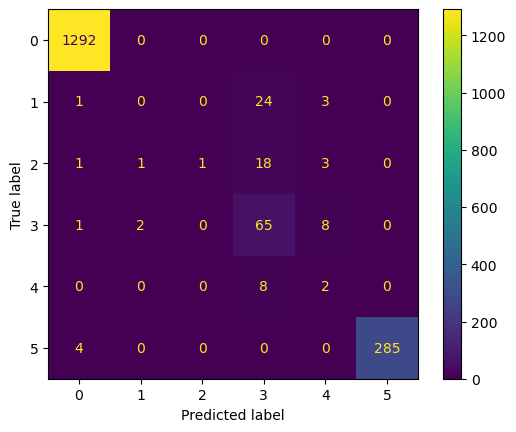

In [119]:
cm_test_rf= confusion_matrix(y_test, y_pred_randfor)
ConfusionMatrixDisplay(cm_test_rf).plot()

In [120]:
eval_randfor = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [cm_test_rf[1, 0], mae, kappa]
}

In [121]:
evaluation= pd.DataFrame({'logistic_regression': eval_logreg['Score'], 'random_forest': eval_randfor['Score']}, index=eval_logreg['Metric'])

Text(0.5, 1.0, 'Model Evaluation Comparison')

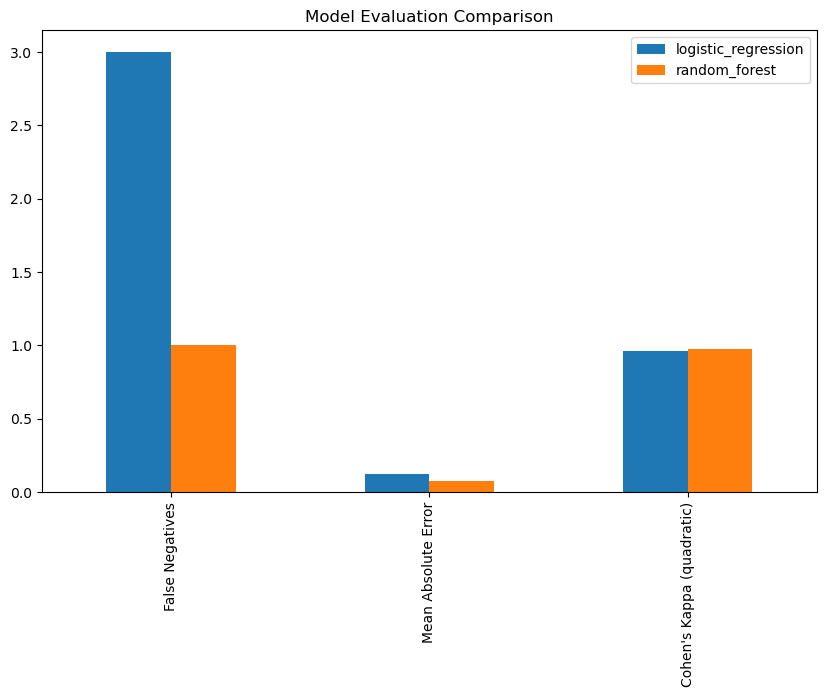

In [122]:
evaluation.plot(kind='bar', figsize=(10, 6), edgecolor='none')
plt.title('Model Evaluation Comparison')

In [125]:
pipe_rf.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'smote', 'FunctionTransformer', 'classifier', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num_scaler', 'preprocessor__num_minmax', 'preprocessor__cat_onehot', 'preprocessor__cat_grade', 'preprocessor__cat_emp_status', 'preprocessor__cat_verification', 'preprocessor__num_scaler__memory', 'preprocessor__num_scaler__steps', 'preprocessor__num_scaler__transform_input', 'preprocessor__num_scaler__verbose', 'preprocessor__num_scaler__scaler', 'preprocessor__num_scaler__scaler__copy', 'preprocessor__num_scaler__scaler__with_mean', 'preprocessor__num_scaler__scaler__with_std', 'preprocessor__num_minmax__memory', 'preprocessor__num_minmax__steps', 'preprocessor__num_minmax__transform_input',

In [129]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10]
}

grid_search = GridSearchCV(pipe_rf, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters found:  {'classifier__max_depth': None, 'classifier__n_estimators': 200}


In [130]:
y_pred_randfor_tuned = grid_search.predict(X_test)

In [131]:
print(classification_report(y_test, y_pred_randfor_tuned))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1292
           1       0.00      0.00      0.00        28
           2       1.00      0.04      0.08        24
           3       0.56      0.86      0.68        76
           4       0.12      0.20      0.15        10
           5       1.00      0.98      0.99       289

    accuracy                           0.96      1719
   macro avg       0.61      0.51      0.48      1719
weighted avg       0.95      0.96      0.95      1719



In [132]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_randfor_tuned)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_randfor_tuned, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0774
Cohen's Kappa (quadratic): 0.9752


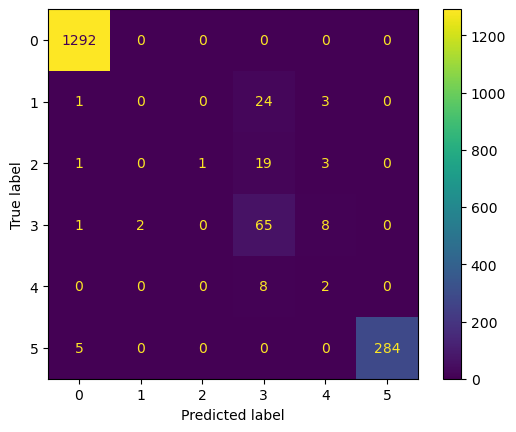

In [133]:
cm_test_tuned= confusion_matrix(y_test, y_pred_randfor_tuned)
ConfusionMatrixDisplay(cm_test_tuned).plot()

In [134]:
eval_tuned_rf = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [cm_test_tuned[1, 0], mae, kappa]
}

In [139]:
evaluation['tuned_random_forest'] = eval_tuned_rf['Score']

Text(0.5, 1.0, 'Model Evaluation Comparison')

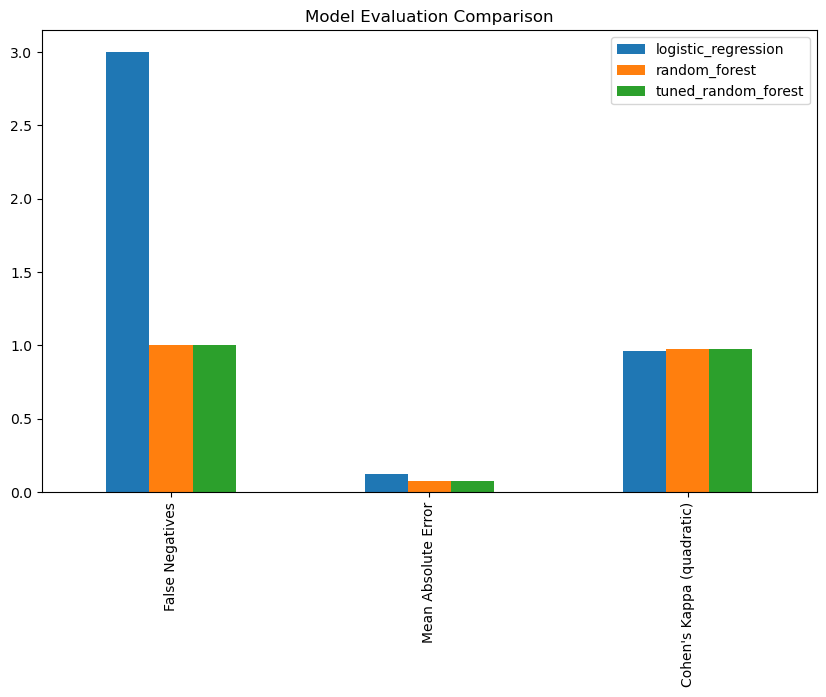

In [140]:
evaluation.plot(kind='bar', figsize=(10, 6), edgecolor='none')
plt.title('Model Evaluation Comparison')

In [141]:
evaluation

,logistic_regression,random_forest,tuned_random_forest
False Negatives,3.000000,1.000000,1.000000
Mean Absolute Error,0.121582,0.074462,0.077371
Cohen's Kappa (quadratic),0.962888,0.977166,0.975191


In [144]:
model_best = grid_search.best_estimator_
joblib.dump(model_best, open('model_best.pkl', 'wb'))

In [145]:
model_best

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaler', ...), ('num_minmax', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready 